# 01 · Encoding & tuning WiSARD — the heart of the problem

For a weightless network, **the encoding *is* the model design.** A WiSARD has no weights
to compensate for a bad representation: each RAM simply memorises which `address`-bit
tuples it saw for each class, and recognition is a majority vote of RAM lookups. So two
choices decide everything:

1. **Binarisation** — how a continuous RGB patch becomes bits (the *thermometer* and its
   resolution).
2. **Mapping into RAMs** — how those bits are grouped into tuples (the *address size*).

This notebook treats both seriously: what the binarisation looks like, why the choices
matter, and a **comprehensive grid search** over thermometer *type* × *size* (2–16) ×
*address size* (2–16). The winning configuration is saved and carried into the benchmark
in **02**. We keep the model itself plain — a single vanilla `Wisard` — so that *all* the
variation we see comes from the representation, not the classifier.

In [1]:
import sys, os, json, importlib, time
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import synthetic as S, characters as C, detector as D, bench
for _m in (S, C, D, bench): importlib.reload(_m)
import wisardpkg as wp
from sklearn.metrics import f1_score
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True)
CACHE_DIR = './cache'

## Why binarisation matters (for WiSARD specifically)
LR and RF take the raw float pixels and *learn* what matters (weights, splits). A WiSARD
can't: it indexes RAMs by raw bit-patterns. If the binarisation throws away the
distinction between Waldo's red and Odlaw's yellow, no amount of training recovers it —
the information never entered the model. That is why, for weightless networks, picking
the encoding is the bulk of the modelling effort.

## The thermometer encoding
A scalar value $v\in[0,1]$ (one colour channel of one pixel) becomes `size` bits, where
bit $k$ is $[\,v \ge \theta_k\,]$ — a "filled bar" that rises with the value. The set of
thresholds $\{\theta_k\}$ — *the thermometer* — is the real design choice. Three kinds:

- **simple** — thresholds evenly spaced in $[0,1]$ (ignores how the data is distributed);
- **distributive** — thresholds at the data's empirical **quantiles** (equal mass per
  bin, so resolution goes where the values actually are);
- **gaussian** — thresholds spaced under a fitted Normal (mean/std of the channel).

We fit the thresholds on the **training** pixels and reuse them on test (no leakage).

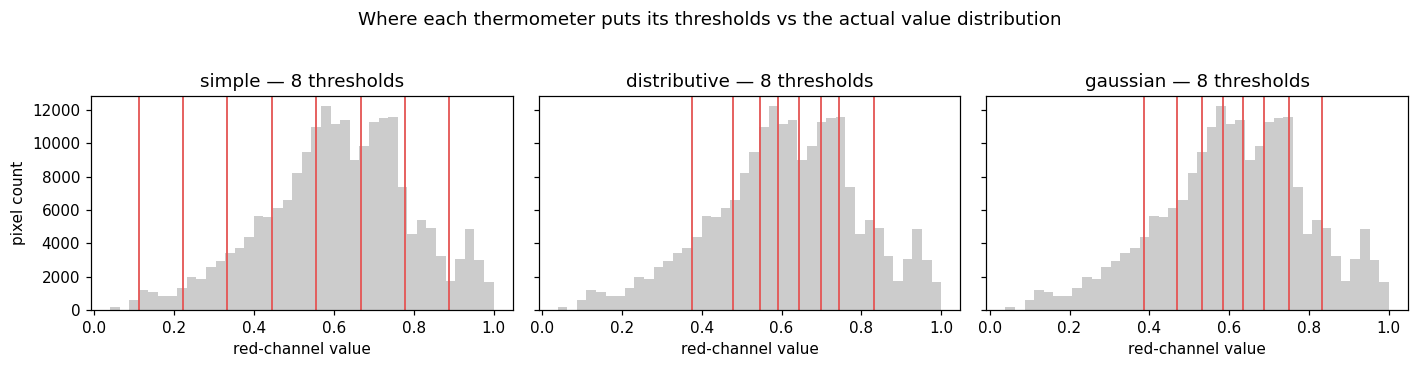

In [2]:
# A small clean set to illustrate the encoding.
Xraw, ylab = C.make_dataset(60, size=48, seed=0, **C.PRESETS['clean'])
Xc = bench.to_canon(Xraw, 24)
ch, ch_name = 0, 'red'
vals = (Xc[..., ch] / 255.0).ravel()
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for a, kind in zip(ax, bench.THERM_KINDS):
    a.hist(vals, bins=40, color='#cccccc')
    for t in bench.fit_thermometer(Xc, kind, 8)[ch]:
        a.axvline(t, color='#E45756', lw=1.2)
    a.set_title(f'{kind} — 8 thresholds'); a.set_xlabel(f'{ch_name}-channel value')
ax[0].set_ylabel('pixel count')
plt.suptitle('Where each thermometer puts its thresholds vs the actual value distribution', y=1.03)
plt.tight_layout(); plt.show()

Notice the **bimodality**: pixels pile up near 0 (dark/blue background, non-red channels)
and near 1 (saturated red/white). *simple* wastes thresholds on the empty middle;
*distributive* clusters them on the two modes. Whether that helps is an empirical
question — which is exactly what the grid search answers.

### What the bits actually look like
To recognise a character the encoding must preserve the two things that identify it: its
**colour** (Waldo's red/white vs Odlaw's black/yellow) and the **spatial layout** of that
colour (horizontal stripes, a partial band, …). The per-channel thermometer captures both.
A clarification up front: this thermometer is **generic** — it just quantises each raw R/G/B
channel; we do *not* hand-pick "Waldo-red." (The explicitly hand-crafted colour features —
the *colormask* `is_red`/`is_white`/`is_dark` — are a separate encoding we compare in **02**.)

#### Colour → a per-channel signature
Each pixel's three channels are thermometer-coded *independently*, so a colour is identified
by the **combination** of how many bits fire in each channel:

| pixel colour | R bits | G bits | B bits | where it appears |
|---|---|---|---|---|
| red    | many | few  | few  | Waldo / Wenda / Woof stripes |
| white  | many | many | many | Waldo / Wenda stripes |
| yellow | many | **many** | few | **Odlaw** stripes |
| black  | few  | few  | few  | Odlaw stripes, dark clutter |
| blue   | few  | few  | many | trousers, background |

So Waldo-red and Odlaw-yellow differ *almost only in the green channel* — and the
thermometer keeps that difference explicit. Below, the per-channel activation (number of
bits on, 0–8) for a Waldo vs an Odlaw patch:

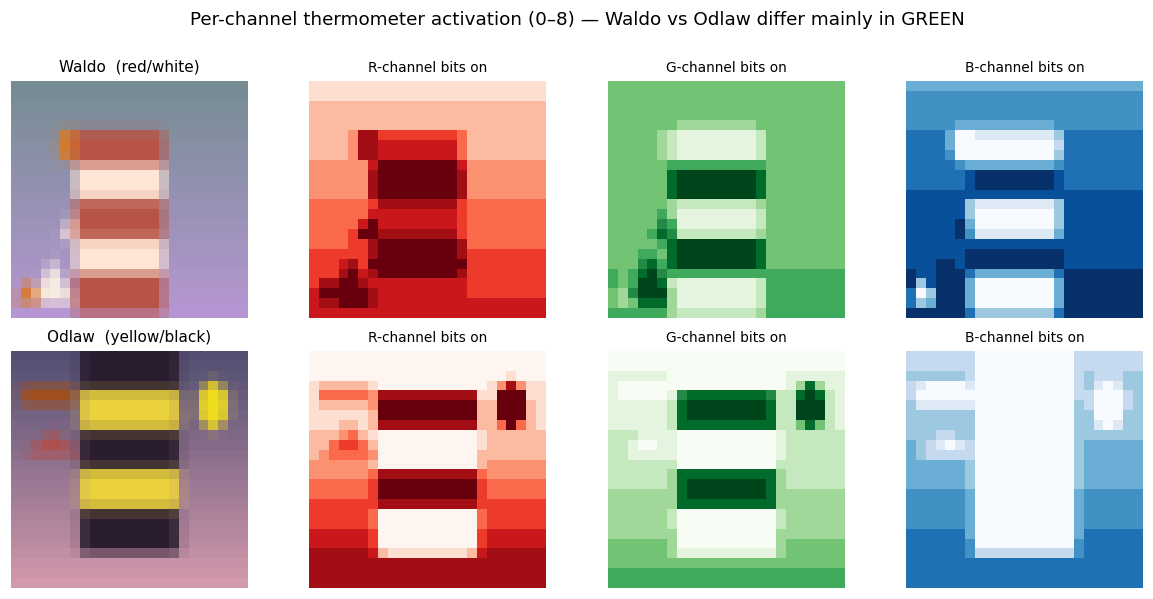

In [3]:
THSIZE = 8
th_ill = bench.fit_thermometer(Xc, 'distributive', THSIZE)
planes = bench.thermometer_encode(Xc, th_ill).reshape(len(Xc), 24, 24, 3, THSIZE)
counts = planes.sum(-1)                       # (N,24,24,3) bits-on per channel, in [0, THSIZE]
iw = int(np.where(ylab == C.CLASS_TO_IDX['waldo'])[0][0])
io = int(np.where(ylab == C.CLASS_TO_IDX['odlaw'])[0][0])
fig, ax = plt.subplots(2, 4, figsize=(11, 5.4))
for row, (idx, name) in enumerate([(iw, 'Waldo  (red/white)'), (io, 'Odlaw  (yellow/black)')]):
    ax[row, 0].imshow(Xc[idx]); ax[row, 0].set_title(name, fontsize=10); ax[row, 0].axis('off')
    for ci, (cn, cmap) in enumerate([('R', 'Reds'), ('G', 'Greens'), ('B', 'Blues')]):
        ax[row, ci + 1].imshow(counts[idx, :, :, ci], cmap=cmap, vmin=0, vmax=THSIZE)
        ax[row, ci + 1].set_title(f'{cn}-channel bits on', fontsize=9); ax[row, ci + 1].axis('off')
plt.suptitle('Per-channel thermometer activation (0–8) — Waldo vs Odlaw differ mainly in GREEN', y=1.0)
plt.tight_layout(); plt.show()

The stripes light up the **R** channel for both, but only Odlaw also lights up **G**
(red + green = yellow). That single-channel difference is what lets WiSARD separate the
target from its "awful opposite".

#### Position is preserved
The bit-image stays **spatially aligned** with the patch — every pixel keeps its location.
WiSARD's RAMs then sample *local tuples* of these position-tagged bits, so *where* the
red/white alternation happens is part of the address. That is why the stripe **layout**
(Waldo's even stripes vs Wenda's spacing vs Woof's partial band) is recoverable even though
all three share the same palette. Here is one channel's thermometer "filling up" for Waldo:

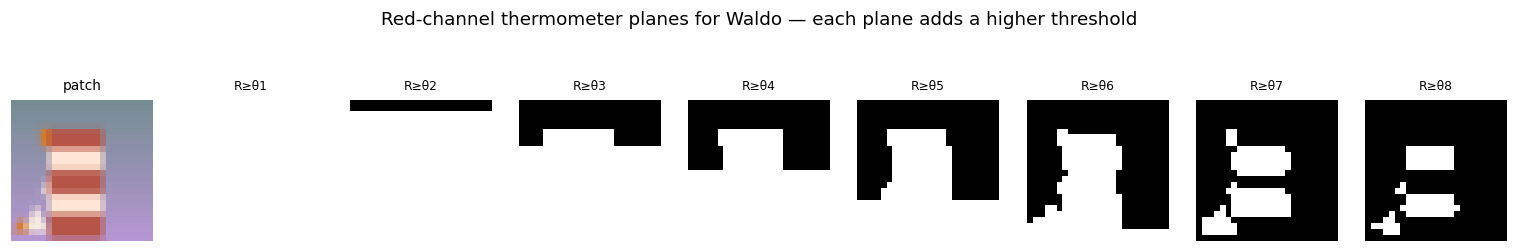

In [4]:
fig, ax = plt.subplots(1, THSIZE + 1, figsize=(14, 1.9))
ax[0].imshow(Xc[iw]); ax[0].set_title('patch', fontsize=9); ax[0].axis('off')
for k in range(THSIZE):
    ax[k + 1].imshow(planes[iw, :, :, 0, k], cmap='gray', vmin=0, vmax=1)
    ax[k + 1].set_title(f'R≥θ{k+1}', fontsize=8); ax[k + 1].axis('off')
plt.suptitle('Red-channel thermometer planes for Waldo — each plane adds a higher threshold', y=1.18)
plt.tight_layout(); plt.show()

#### How the classes look in the encoding
Averaging the encoding over many clean patches gives the **prototype** the model effectively sees per class — the characteristic colour *and* layout, rendered back as pseudo-RGB:

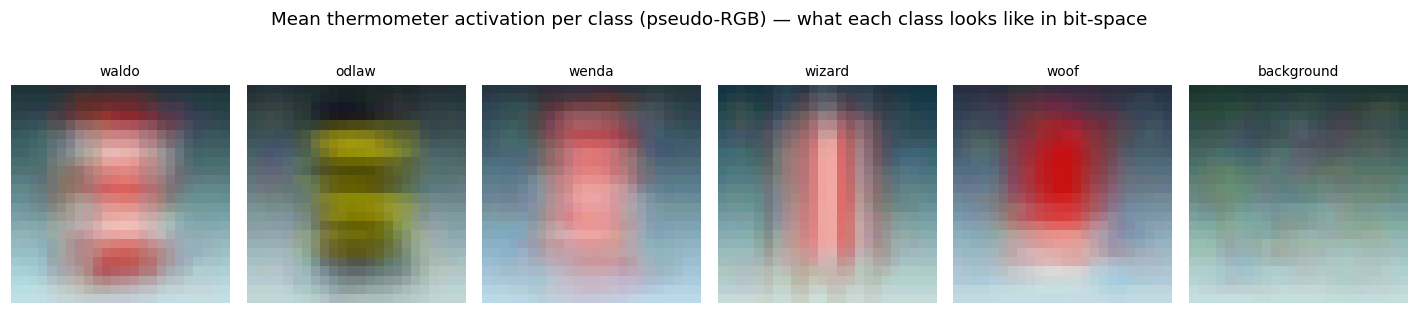

In [5]:
Xp, yp = C.make_dataset(50, size=48, seed=3, **C.PRESETS['clean']); Xp = bench.to_canon(Xp, 24)
thp = bench.fit_thermometer(Xp, 'distributive', THSIZE)
cp = bench.thermometer_encode(Xp, thp).reshape(len(Xp), 24, 24, 3, THSIZE).sum(-1) / THSIZE
fig, ax = plt.subplots(1, len(C.CLASSES), figsize=(13, 2.6))
for a, cls in zip(ax, C.CLASSES):
    a.imshow(np.clip(cp[yp == C.CLASS_TO_IDX[cls]].mean(0), 0, 1))
    a.set_title(cls, fontsize=9); a.axis('off')
plt.suptitle('Mean thermometer activation per class (pseudo-RGB) — what each class looks like in bit-space', y=1.08)
plt.tight_layout(); plt.show()

You can read the discriminators straight off the prototypes: Waldo's even red/white
bands, Odlaw's yellow/black, Wizard's vertical stripes, Woof's partial band, Wenda's
red/white at a different spacing, and `background`'s muddy average. **This** is the
representation WiSARD works from. In **02**, LR and RF instead see the raw float pixels,
and we pit this dense thermometer against the hand-crafted colormask "tone" bits — three
different lenses on the same patch, which is exactly what makes the comparison meaningful.

## Address size & mapping into RAMs
The bit-image is flattened and split into tuples of `address_size` bits; each tuple feeds
one RAM, so **#RAMs ≈ total_bits / address_size**. The split uses a **random mapping**
(WiSARD's default; a spatial `Local2DMapping` is a knob we leave for later).

- **small address** → short, generic tuples → many RAMs, easy matches, *generalises* but
  blurs fine patterns;
- **large address** → long, specific tuples → few RAMs, *discriminative* but data-hungry
  and prone to never matching at test time.

There's a sweet spot, and it interacts with the thermometer size (more bits can feed
larger tuples). The grid below maps it out.

In [6]:
canon = 24
print('total input bits = canon² × 3 channels × thermometer size')
for size in [2, 8, 16]:
    bits = canon * canon * 3 * size
    print(f'  size={size:2d}: {bits:6d} bits  ->  #RAMs at addr 4 / 8 / 16 = '
          f'{bits//4:5d} / {bits//8:5d} / {bits//16:4d}')

total input bits = canon² × 3 channels × thermometer size
  size= 2:   3456 bits  ->  #RAMs at addr 4 / 8 / 16 =   864 /   432 /  216
  size= 8:  13824 bits  ->  #RAMs at addr 4 / 8 / 16 =  3456 /  1728 /  864
  size=16:  27648 bits  ->  #RAMs at addr 4 / 8 / 16 =  6912 /  3456 / 1728


## Comprehensive grid search
**thermometer type × size (2–16) × address size (2–16)**, macro-F1 on the clean preset,
averaged over 3 seeds. This is the expensive cell; results are cached to
`cache/grid_wisard.json` and reloaded on re-run (delete the file to recompute).

In [7]:
CACHE = f'{CACHE_DIR}/grid_wisard.json'
TYPES, SIZES, ADDRS, SEEDS = list(bench.THERM_KINDS), list(range(2, 17)), list(range(2, 17)), [1, 2, 3]
if os.path.exists(CACHE):
    grid = json.load(open(CACHE)); print('loaded cached grid:', len(grid), 'cells')
else:
    print('computing grid (a few minutes)…'); t0 = time.time(); grid = {}
    for seed in SEEDS:
        Xtr, ytr = C.make_dataset(100, size=48, seed=seed, **C.PRESETS['clean']); Xtr = bench.to_canon(Xtr, 24)
        Xte, yte = C.make_dataset(50, size=48, seed=100 + seed, **C.PRESETS['clean']); Xte = bench.to_canon(Xte, 24)
        for kind in TYPES:
            for size in SIZES:
                th = bench.fit_thermometer(Xtr, kind, size)
                Btr, Bte = bench.thermometer_encode(Xtr, th), bench.thermometer_encode(Xte, th)
                ds = wp.DataSet()
                for b, l in zip(Btr, ytr): ds.add(b.tolist(), str(int(l)))
                q = wp.DataSet()
                for b in Bte: q.add(b.tolist(), '0')
                for addr in ADDRS:
                    m = wp.Wisard(addr); m.train(ds)
                    f1 = f1_score(yte, np.array([int(o) for o in m.classify(q)]), average='macro')
                    grid.setdefault(f'{kind}|{size}|{addr}', []).append(round(float(f1), 4))
        print(f'  seed {seed} done @ {time.time()-t0:.0f}s', flush=True)
    os.makedirs(CACHE_DIR, exist_ok=True); json.dump(grid, open(CACHE, 'w'))
gmean = lambda k: float(np.mean(grid[k]))

loaded cached grid: 675 cells


### Heatmaps — F1 over (thermometer size × address size), per thermometer type

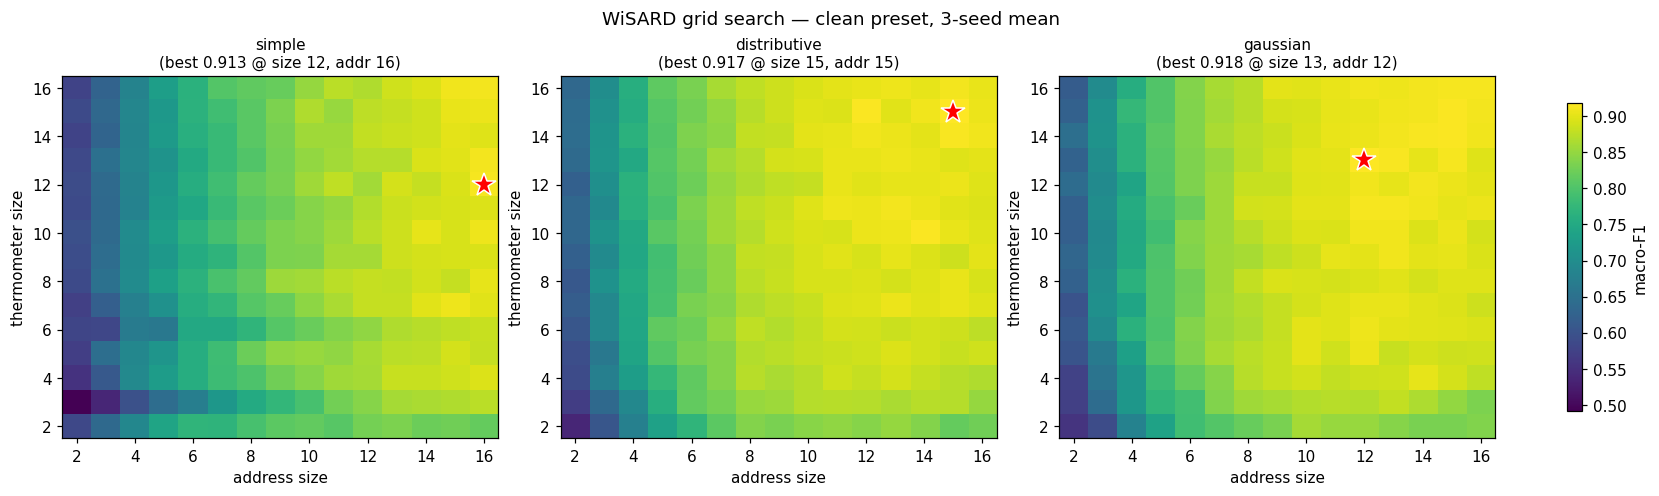

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)
vmin = min(gmean(k) for k in grid); vmax = max(gmean(k) for k in grid)
ticks = list(range(2, 17, 2))
for a, kind in zip(ax, TYPES):
    M = np.array([[gmean(f'{kind}|{s}|{ad}') for ad in ADDRS] for s in SIZES])
    im = a.imshow(M, origin='lower', aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax,
                  extent=[ADDRS[0] - 0.5, ADDRS[-1] + 0.5, SIZES[0] - 0.5, SIZES[-1] + 0.5])
    bi, bj = np.unravel_index(np.argmax(M), M.shape)
    a.plot(ADDRS[bj], SIZES[bi], 'r*', ms=16, mec='white')
    a.set_title(f'{kind}\n(best {M.max():.3f} @ size {SIZES[bi]}, addr {ADDRS[bj]})', fontsize=10)
    a.set_xlabel('address size'); a.set_ylabel('thermometer size')
    a.set_xticks(ticks); a.set_yticks(ticks)
fig.colorbar(im, ax=ax, shrink=0.85, label='macro-F1')
fig.suptitle('WiSARD grid search — clean preset, 3-seed mean')
plt.show()

### Marginals — the address sweet spot and thermometer-size saturation

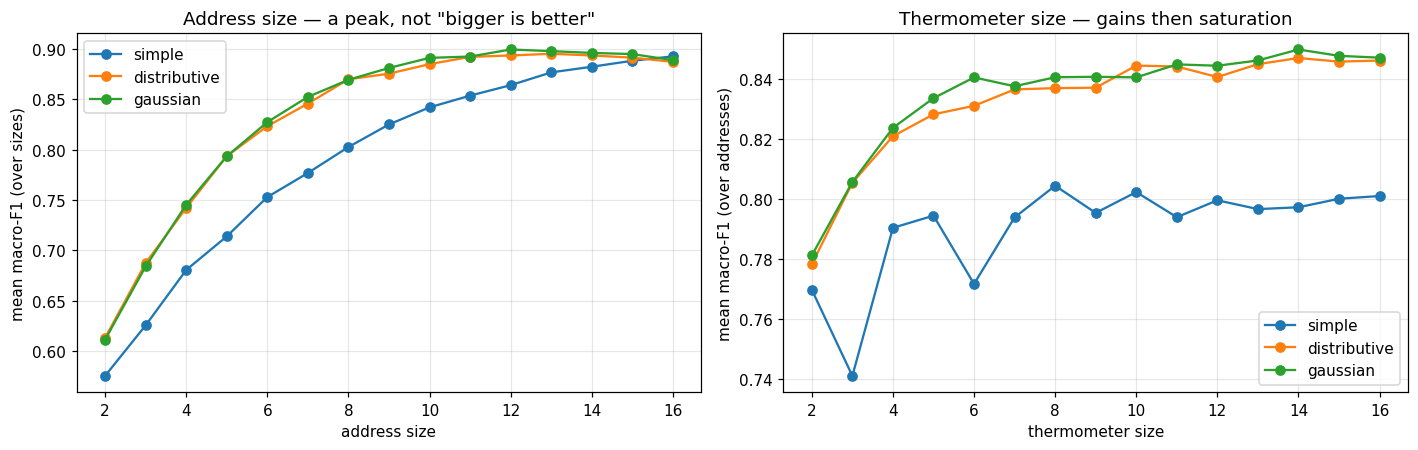

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for kind in TYPES:
    by_addr = [np.mean([gmean(f'{kind}|{s}|{ad}') for s in SIZES]) for ad in ADDRS]
    by_size = [np.mean([gmean(f'{kind}|{s}|{ad}') for ad in ADDRS]) for s in SIZES]
    ax[0].plot(ADDRS, by_addr, '-o', label=kind)
    ax[1].plot(SIZES, by_size, '-o', label=kind)
ax[0].set_xlabel('address size'); ax[0].set_ylabel('mean macro-F1 (over sizes)')
ax[0].set_title('Address size — a peak, not "bigger is better"')
ax[1].set_xlabel('thermometer size'); ax[1].set_ylabel('mean macro-F1 (over addresses)')
ax[1].set_title('Thermometer size — gains then saturation')
for a in ax: a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
# Concrete winners
best = max(grid, key=gmean); bk, bs, ba = best.split('|')
print(f'GLOBAL BEST: {bk} thermometer, size {bs}, address {ba}  ->  F1 = {gmean(best):.3f}')
print('Best per thermometer type:')
for kind in TYPES:
    ks = [k for k in grid if k.startswith(kind + '|')]
    b = max(ks, key=gmean); _, s, a = b.split('|')
    print(f'  {kind:13s}: size {s:>2}, addr {a:>2}  ->  {gmean(b):.3f}')
ba_peak = ADDRS[int(np.argmax([np.mean([gmean(f"distributive|{s}|{ad}") for s in SIZES]) for ad in ADDRS]))]
print(f'\nAddress sweet spot (distributive marginal): {ba_peak}')

GLOBAL BEST: gaussian thermometer, size 13, address 12  ->  F1 = 0.918
Best per thermometer type:
  simple       : size 12, addr 16  ->  0.913
  distributive : size 15, addr 15  ->  0.917
  gaussian     : size 13, addr 12  ->  0.918

Address sweet spot (distributive marginal): 13


### Reading the grid
- **Address size has a peak, not a ramp.** Tiny tuples under-fit (too generic); very large
  tuples stop matching at test time. The best sits in the middle — and that optimum shifts
  *right* as the thermometer grows, the size↔address interaction in action.
- **Thermometer size gives diminishing returns** — accuracy climbs then plateaus; past the
  plateau you only pay memory.
- **Type matters less than folklore suggests here.** Because our palette is near-bimodal,
  *distributive* and *gaussian* barely separate from *simple*. The lesson isn't "always use
  distributive" — it's "the optimum is data-dependent, so search it." 

## The chosen configuration
Lock in the grid winner, measure its full profile (accuracy on clean + full, memory, timing), and save it for notebook **02**.

In [11]:
best_cfg = dict(kind=bk, size=int(bs), addr=int(ba))
def make_wisard_model(cfg, fit_Xc):
    th = bench.fit_thermometer(fit_Xc, cfg['kind'], cfg['size'])
    return bench.WNNModel(f"WiSARD/{cfg['kind']}{cfg['size']}/a{cfg['addr']}",
                          (lambda n, a=cfg['addr']: wp.Wisard(a)),
                          encoder=(lambda Xc, t=th: bench.thermometer_encode(Xc, t)))
rows = []
for preset in ['clean', 'full']:
    Xtr, ytr = C.make_dataset(150, size=48, seed=1, **C.PRESETS[preset])
    Xte, yte = C.make_dataset(60, size=48, seed=2, **C.PRESETS[preset])
    mdl = make_wisard_model(best_cfg, bench.to_canon(Xtr, 24))
    rows.append({'preset': preset, **{k: v for k, v in bench.evaluate(mdl, Xtr, ytr, Xte, yte, canon=24).items() if k != 'model'}})
json.dump(best_cfg, open(f'{CACHE_DIR}/best_wisard.json', 'w'))
print('saved best config ->', best_cfg)
pd.DataFrame(rows).set_index('preset')

saved best config -> {'kind': 'gaussian', 'size': 13, 'addr': 12}


,f1,acc,train_s,infer_ms,mem_kb
preset,,,,,
clean,0.906,0.906,0.394,1.274,10010.5
full,0.717,0.714,0.403,1.404,12099.2


### A note on compact encodings
The thermometer is dense (its memory grows with `size`). The hand-designed **colormask**
(3 semantic bits/pixel) is ~8× smaller — a different point on the accuracy/memory trade-off
we'll map fully in **02**. A quick head-to-head at the chosen address size:

In [12]:
Xtr, ytr = C.make_dataset(150, size=48, seed=1, **C.PRESETS['clean'])
Xte, yte = C.make_dataset(60, size=48, seed=2, **C.PRESETS['clean'])
comp = []
for name, enc in [(f"thermometer ({best_cfg['kind']} {best_cfg['size']})",
                   (lambda Xc: bench.thermometer_encode(Xc, bench.fit_thermometer(bench.to_canon(Xtr,24), best_cfg['kind'], best_cfg['size'])))),
                  ('colormask (3-bit)', bench.ENCODERS['colormask']),
                  ('colormask+stripe (4-bit)', bench.ENCODERS['colormask+stripe'])]:
    mdl = bench.WNNModel(name, lambda n, a=best_cfg['addr']: wp.Wisard(a), encoder=enc)
    r = bench.evaluate(mdl, Xtr, ytr, Xte, yte, canon=24)
    comp.append({'encoding': name, 'F1 (clean)': r['f1'], 'memory (KB)': r['mem_kb'], 'infer (ms)': r['infer_ms']})
pd.DataFrame(comp).set_index('encoding')

,F1 (clean),memory (KB),infer (ms)
encoding,,,
thermometer (gaussian 13),0.898,10011.3,1.333
colormask (3-bit),0.705,379.4,0.063
colormask+stripe (4-bit),0.719,452.0,0.156


## Takeaways
- For WiSARD the **representation is the model**: the thermometer (type + resolution) and
  the address size jointly set accuracy and memory, and both have **interior optima** —
  bigger is *not* always better.
- A comprehensive grid is worth it: the winner (printed above) does **not** vindicate the
  "distributive is always best" folklore on this near-bimodal palette — *search beats
  assumption*, and the address sweet spot is mid-range, not maximal.
- The dense thermometer maximises accuracy; the compact colormask trades accuracy for ~8×
  less memory — the trade-off we turn into a full Pareto, with tuned LR/RF foils and error
  analysis, in **02**.